# 📘 Capítulo 1 – Fundamentos de Séries Temporais
**Autor:** Rodrigo Santana Ferreira  
**Disciplina:** Séries Temporais  

---
Este notebook contém os scripts Python apresentados no Capítulo 1, organizados por seção conforme o material da aula.

## 🔧 Instalação de Dependências

In [3]:
# Instalação das bibliotecas necessárias
!pip install pandas matplotlib statsmodels

## 📊 Trabalhando com série temporal com Python

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset

In [5]:
# Carregar o dataset AirPassengers embutido no statsmodels
air = get_rdataset("AirPassengers").data

In [6]:
air.head(10)

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121
5,1949.416667,135
6,1949.500000,148
7,1949.583333,148
8,1949.666667,136
9,1949.750000,119


In [7]:
# Cria um índice de data mensal para o DataFrame 'air', começando em janeiro de 1949 e com a duração do DataFrame.
air.index = pd.date_range(start='1949-01', periods=len(air), freq='M')

/tmp/ipykernel_8105/3579976098.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  air.index = pd.date_range(start='1949-01', periods=len(air), freq='M')


In [8]:
air.head()

,time,value
1949-01-31,1949.000000,112
1949-02-28,1949.083333,118
1949-03-31,1949.166667,132
1949-04-30,1949.250000,129
1949-05-31,1949.333333,121


In [9]:
# Extrai a coluna 'value' do DataFrame 'air' e a converte para o tipo float, armazenando-a na variável 'data'.
data = air['value'].astype(float)

In [11]:
# Exibe as primeiras linhas da série temporal original para contexto.
print("Série Temporal Original (Primeiras Linhas):")
print(data.head(10))

Série Temporal Original (Primeiras Linhas):
1949-01-31    112.0
1949-02-28    118.0
1949-03-31    132.0
1949-04-30    129.0
1949-05-31    121.0
1949-06-30    135.0
1949-07-31    148.0
1949-08-31    148.0
1949-09-30    136.0
1949-10-31    119.0
Freq: ME, Name: value, dtype: float64


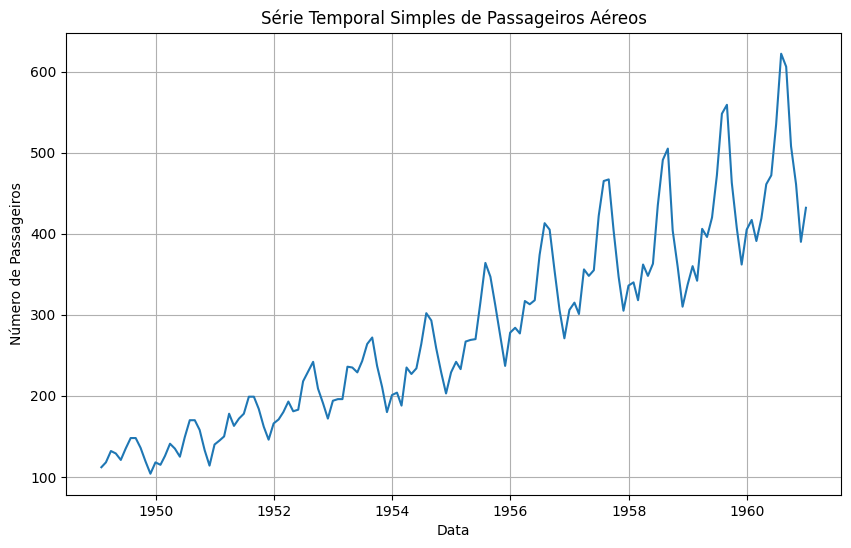

In [12]:
# Importa a biblioteca matplotlib para criar gráficos
import matplotlib.pyplot as plt

# Cria uma nova figura e um conjunto de eixos para o gráfico
plt.figure(figsize=(10, 6))
# Plota a série temporal 'data'
plt.plot(data)
# Define o título do gráfico
plt.title('Série Temporal Simples de Passageiros Aéreos')
# Define o rótulo do eixo X
plt.xlabel('Data')
# Define o rótulo do eixo Y
plt.ylabel('Número de Passageiros')
# Adiciona uma grade ao gráfico para melhor visualização
plt.grid(True)
# Exibe o gráfico
plt.show()

## Manipulando dataframes com a biblioteca Pandas

In [13]:
# Realiza a reamostragem dos dados para um período trimestral, calculando a média de cada trimestre.
resampled_data = data.resample('Q').mean()

/tmp/ipykernel_8105/1942851527.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  resampled_data = data.resample('Q').mean()


In [15]:
# Exibe as primeiras linhas da série temporal reamostrada.
print("\nSérie Temporal Reamostrada (Trimestral - Média):")
print(resampled_data.head(12))


Série Temporal Reamostrada (Trimestral - Média):
1949-03-31    120.666667
1949-06-30    128.333333
1949-09-30    144.000000
1949-12-31    113.666667
1950-03-31    127.333333
1950-06-30    136.333333
1950-09-30    166.000000
1950-12-31    129.000000
1951-03-31    157.666667
1951-06-30    171.000000
1951-09-30    194.000000
1951-12-31    158.000000
Freq: QE-DEC, Name: value, dtype: float64


In [16]:
# Calcula a média móvel dos últimos 12 períodos (meses) para suavizar a série temporal.
rolling_mean = data.rolling(window=12).mean()

In [18]:
# Exibe as primeiras linhas da média móvel.
print("\nMédia Móvel (Janela de 12 meses):")
print(rolling_mean.head(30))


Média Móvel (Janela de 12 meses):
1949-01-31           NaN
1949-02-28           NaN
1949-03-31           NaN
1949-04-30           NaN
1949-05-31           NaN
1949-06-30           NaN
1949-07-31           NaN
1949-08-31           NaN
1949-09-30           NaN
1949-10-31           NaN
1949-11-30           NaN
1949-12-31    126.666667
1950-01-31    126.916667
1950-02-28    127.583333
1950-03-31    128.333333
1950-04-30    128.833333
1950-05-31    129.166667
1950-06-30    130.333333
1950-07-31    132.166667
1950-08-31    134.000000
1950-09-30    135.833333
1950-10-31    137.000000
1950-11-30    137.833333
1950-12-31    139.666667
1951-01-31    142.166667
1951-02-28    144.166667
1951-03-31    147.250000
1951-04-30    149.583333
1951-05-31    153.500000
1951-06-30    155.916667
Freq: ME, Name: value, dtype: float64


In [19]:
# Desloca a série temporal em 1 período para trás, útil para calcular diferenças ou comparar com o valor anterior.
shifted_data = data.shift(1)

In [20]:
# Exibe as primeiras linhas da série temporal deslocada.
print("\nSérie Temporal Deslocada (1 período):")
print(shifted_data.head(20))


Série Temporal Deslocada (1 período):
1949-01-31      NaN
1949-02-28    112.0
1949-03-31    118.0
1949-04-30    132.0
1949-05-31    129.0
1949-06-30    121.0
1949-07-31    135.0
1949-08-31    148.0
1949-09-30    148.0
1949-10-31    136.0
1949-11-30    119.0
1949-12-31    104.0
1950-01-31    118.0
1950-02-28    115.0
1950-03-31    126.0
1950-04-30    141.0
1950-05-31    135.0
1950-06-30    125.0
1950-07-31    149.0
1950-08-31    170.0
Freq: ME, Name: value, dtype: float64


In [21]:
# Aplicar diferenciação para remover tendência
# Calcula a diferença entre um valor e o valor anterior da série temporal.
# O .dropna() remove o primeiro valor (NaN) resultante da diferenciação.
data_diff = data.diff().dropna()

In [22]:
#  Visualiza a série após a diferenciação
data_diff.head(20)

,value
1949-02-28,6.0
1949-03-31,14.0
1949-04-30,-3.0
1949-05-31,-8.0
1949-06-30,14.0
1949-07-31,13.0
1949-08-31,0.0
1949-09-30,-12.0
1949-10-31,-17.0
1949-11-30,-15.0


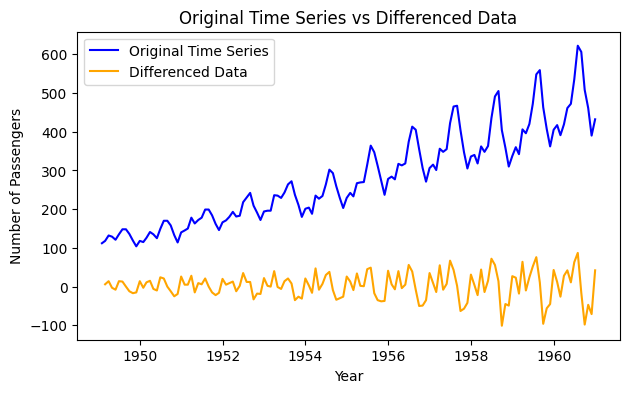

In [23]:
# Plotar série original vs série diferenciada
# Cria uma nova figura para o gráfico com um tamanho específico.
plt.figure(figsize=(7, 4))
# Plota a série temporal original.
plt.plot(data, label='Original Time Series', color='blue')
# Plota a série temporal diferenciada.
plt.plot(data_diff, label='Differenced Data', color='orange')
# Define o título do gráfico.
plt.title('Original Time Series vs Differenced Data')
# Define o rótulo do eixo X.
plt.xlabel('Year')
# Define o rótulo do eixo Y.
plt.ylabel('Number of Passengers')
# Exibe a legenda do gráfico.
plt.legend()
# Exibe o gráfico.
plt.show()


 **Médias móveis**




In [24]:
# serie original
data.head()

,value
1949-01-31,112.0
1949-02-28,118.0
1949-03-31,132.0
1949-04-30,129.0
1949-05-31,121.0


In [25]:
# Calcula a média móvel com uma janela de 3 períodos (curto prazo) para suavizar flutuações de curto prazo.
moving_avg_3 = data.rolling(window=3).mean()

In [26]:
moving_avg_3.head(20)

,value
1949-01-31,NaN
1949-02-28,NaN
1949-03-31,120.666667
1949-04-30,126.333333
1949-05-31,127.333333
1949-06-30,128.333333
1949-07-31,134.666667
1949-08-31,143.666667
1949-09-30,144.000000
1949-10-31,134.333333


In [27]:
# imprime a série após a média móvel
moving_avg_3.head(20)

,value
1949-01-31,NaN
1949-02-28,NaN
1949-03-31,120.666667
1949-04-30,126.333333
1949-05-31,127.333333
1949-06-30,128.333333
1949-07-31,134.666667
1949-08-31,143.666667
1949-09-30,144.000000
1949-10-31,134.333333


In [28]:
# Calcula a média móvel com uma janela de 12 períodos (longo prazo) para capturar tendências de longo prazo.
moving_avg_12 = data.rolling(window=12).mean()

In [29]:
# imprime a série após a média móvel
moving_avg_12.head(20)

,value
1949-01-31,NaN
1949-02-28,NaN
1949-03-31,NaN
1949-04-30,NaN
1949-05-31,NaN
1949-06-30,NaN
1949-07-31,NaN
1949-08-31,NaN
1949-09-30,NaN
1949-10-31,NaN


In [30]:
# Cria uma nova figura e um conjunto de eixos para o gráfico com um tamanho específico.
plt.figure(figsize=(12, 7))

<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

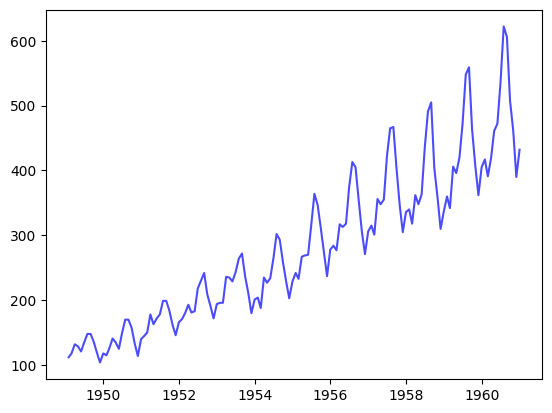

In [31]:
# Plota a série temporal original para comparação.
plt.plot(data, label='Série Temporal Original', color='blue', alpha=0.7)


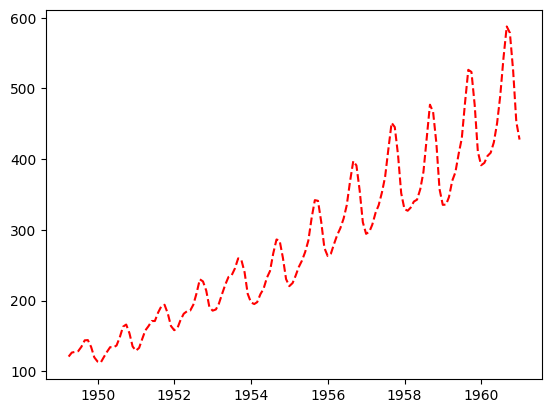

In [32]:
# Plota a média móvel de 3 períodos.
plt.plot(moving_avg_3, label='Média Móvel (3 Meses)', color='red', linestyle='--')

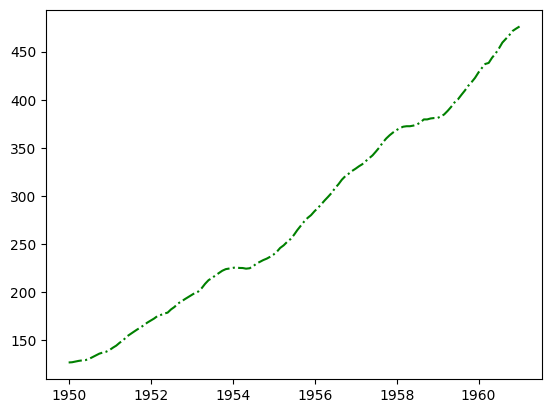

In [33]:
# Plota a média móvel de 12 períodos.
plt.plot(moving_avg_12, label='Média Móvel (12 Meses)', color='green', linestyle='-.')

##**Trablhando com Sazonalidade, Tendência e Resíduos**

In [34]:
# Importa a função seasonal_decompose da biblioteca statsmodels.tsa.seasonal
from statsmodels.tsa.seasonal import seasonal_decompose

In [35]:
# Realiza a decomposição da série temporal 'data'
# 'model="multiplicative"' indica que a sazonalidade é proporcional ao nível da série
# 'period=12' especifica que o padrão sazonal se repete a cada 12 meses (dados mensais)
decomposition = seasonal_decompose(data, model='multiplicative', period=12)

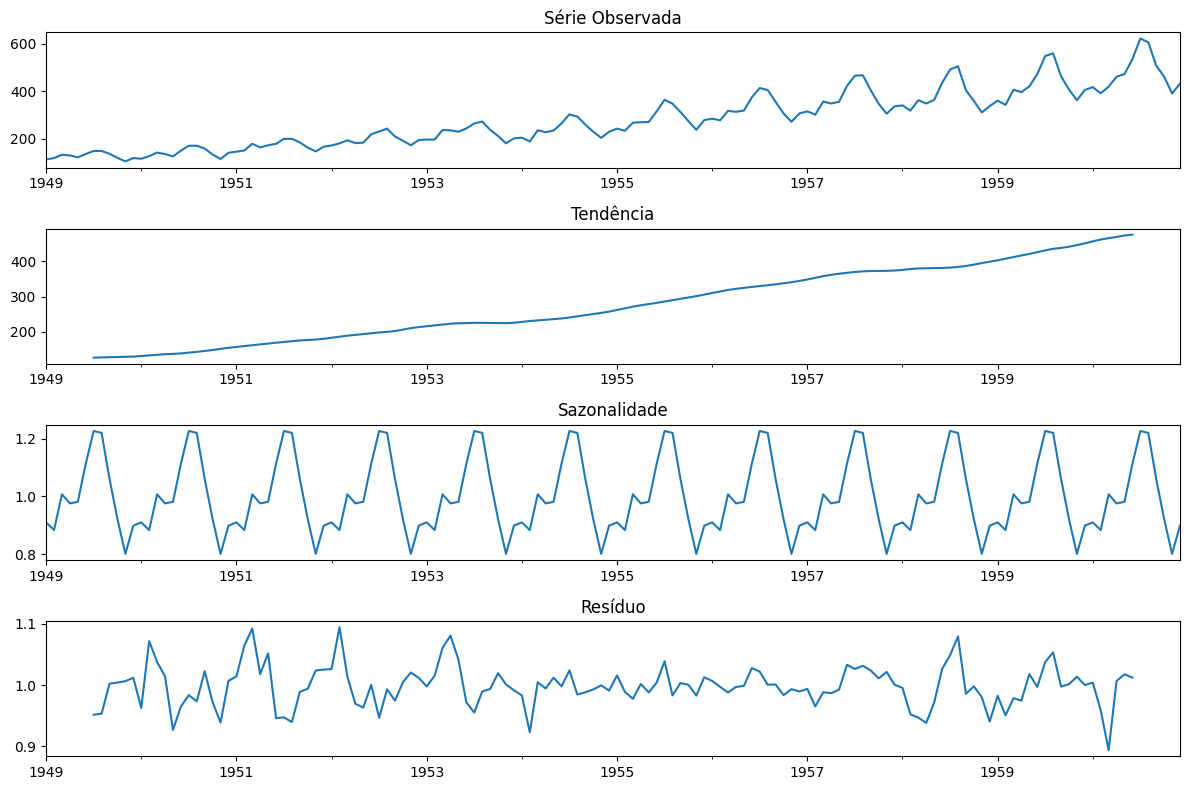

In [36]:
# Cria uma figura e um conjunto de subplots para visualizar a decomposição
# Cada subplot mostrará um componente da série temporal
plt.figure(figsize=(12, 8))

# Plota a série original observada
# O método .plot() da decomposição é usado para desenhar os componentes
decomposition.observed.plot(ax=plt.subplot(4, 1, 1))
# Define o título do subplot
plt.title('Série Observada')

# Plota o componente de tendência
decomposition.trend.plot(ax=plt.subplot(4, 1, 2))
# Define o título do subplot
plt.title('Tendência')

# Plota o componente sazonal
decomposition.seasonal.plot(ax=plt.subplot(4, 1, 3))
# Define o título do subplot
plt.title('Sazonalidade')

# Plota o componente residual (ruído)
decomposition.resid.plot(ax=plt.subplot(4, 1, 4))
# Define o título do subplot
plt.title('Resíduo')

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()
# Exibe o gráfico completo
plt.show()

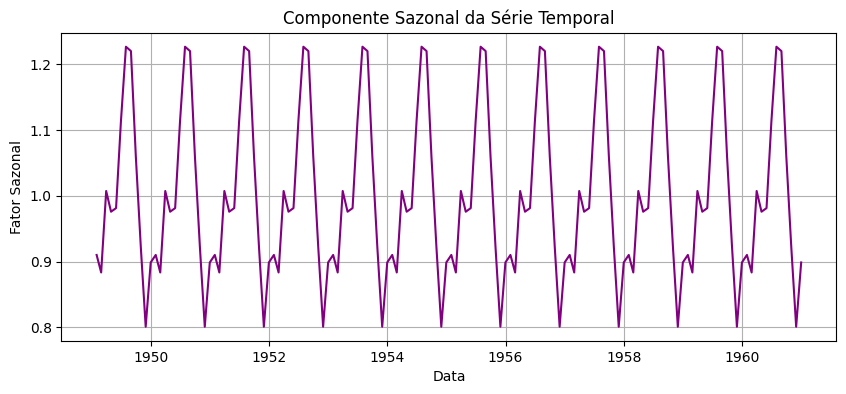

In [37]:
# Para analisar o componente sazonal individualmente, podemos plotá-lo separadamente.
plt.figure(figsize=(10, 4))
# Acessa e plota o componente sazonal da decomposição.
plt.plot(decomposition.seasonal, color='purple')
# Define o título do gráfico do componente sazonal.
plt.title('Componente Sazonal da Série Temporal')
# Define o rótulo do eixo X.
plt.xlabel('Data')
# Define o rótulo do eixo Y, indicando o fator ou efeito sazonal.
plt.ylabel('Fator Sazonal')
# Adiciona uma grade ao gráfico para facilitar a leitura dos valores.
plt.grid(True)
# Exibe o gráfico do componente sazonal.
plt.show()

**Normalização e subtração/multiplicação do resíduo**

In [38]:
# O componente residual ('resid') da decomposição representa o que resta da série após remover a tendência e a sazonalidade.
# Ele é considerado o 'ruído' ou o 'erro' da série.
residuals = decomposition.resid

In [39]:
# Exibe as primeiras linhas dos resíduos para inspeção.
print("Resíduos da Decomposição (Primeiras Linhas):")
print(residuals.head(50))

Resíduos da Decomposição (Primeiras Linhas):
1949-01-31         NaN
1949-02-28         NaN
1949-03-31         NaN
1949-04-30         NaN
1949-05-31         NaN
1949-06-30         NaN
1949-07-31    0.951664
1949-08-31    0.953401
1949-09-30    1.002220
1949-10-31    1.004028
1949-11-30    1.006270
1949-12-31    1.011812
1950-01-31    0.962603
1950-02-28    1.071467
1950-03-31    1.037447
1950-04-30    1.014048
1950-05-31    0.926903
1950-06-30    0.965041
1950-07-31    0.983557
1950-08-31    0.973372
1950-09-30    1.022505
1950-10-31    0.972193
1950-11-30    0.938953
1950-12-31    1.006791
1951-01-31    1.013845
1951-02-28    1.064018
1951-03-31    1.091854
1951-04-30    1.017665
1951-05-31    1.051583
1951-06-30    0.946044
1951-07-31    0.947404
1951-08-31    0.939760
1951-09-30    0.988864
1951-10-31    0.993881
1951-11-30    1.023534
1951-12-31    1.025082
1952-01-31    1.025881
1952-02-29    1.093970
1952-03-31    1.013473
1952-04-30    0.969560
1952-05-31    0.963267
1952-06-30  

In [40]:
# Exibe algumas estatísticas descritivas dos resíduos, como média, desvio padrão, etc.
print("\nEstatísticas Descritivas dos Resíduos:")
print(residuals.describe())


Estatísticas Descritivas dos Resíduos:
count    132.000000
mean       0.998236
std        0.033388
min        0.894086
25%        0.982927
50%        0.998219
75%        1.015225
max        1.093970
Name: resid, dtype: float64


In [41]:
# Normalização dos resíduos (exemplo usando Z-score):
# A normalização é útil para padronizar os resíduos, colocando-os em uma escala comum.
# Isso pode ser importante para certos modelos ou para comparar a variabilidade.
# Calculamos a média dos resíduos (ignorando valores NaN, que são comuns no início e fim da decomposição).
mean_residuals = residuals.mean()

In [42]:
# Calculamos o desvio padrão dos resíduos (ignorando valores NaN).
std_residuals = residuals.std()

In [43]:
# Aplica a normalização Z-score: (valor - média) / desvio padrão.
# Isso transforma os resíduos para que tenham média 0 e desvio padrão 1 (aproximadamente).
normalized_residuals = (residuals - mean_residuals) / std_residuals

In [44]:
# Exibe as primeiras linhas dos resíduos normalizados.
print("\nResíduos Normalizados (Z-score - Primeiras Linhas):")
print(normalized_residuals.head(20))


Resíduos Normalizados (Z-score - Primeiras Linhas):
1949-01-31         NaN
1949-02-28         NaN
1949-03-31         NaN
1949-04-30         NaN
1949-05-31         NaN
1949-06-30         NaN
1949-07-31   -1.394836
1949-08-31   -1.342809
1949-09-30    0.119326
1949-10-31    0.173477
1949-11-30    0.240636
1949-12-31    0.406616
1950-01-31   -1.067217
1950-02-28    2.193311
1950-03-31    1.174413
1950-04-30    0.473576
1950-05-31   -2.136452
1950-06-30   -0.994209
1950-07-31   -0.439647
1950-08-31   -0.744678
Freq: ME, Name: resid, dtype: float64


In [45]:
# Exibe as estatísticas dos resíduos normalizados para verificar se a média está próxima de 0 e o desvio padrão próximo de 1.
print("\nEstatísticas Descritivas dos Resíduos Normalizados:")
print(normalized_residuals.describe())


Estatísticas Descritivas dos Resíduos Normalizados:
count    1.320000e+02
mean     5.843810e-15
std      1.000000e+00
min     -3.119347e+00
25%     -4.585068e-01
50%     -4.922007e-04
75%      5.088281e-01
max      2.867281e+00
Name: resid, dtype: float64


**Demonstração em Python com seasonal_decompose (statsmodels)**

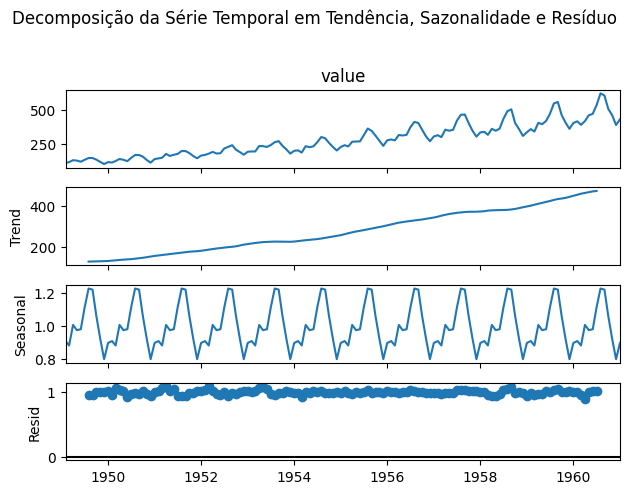

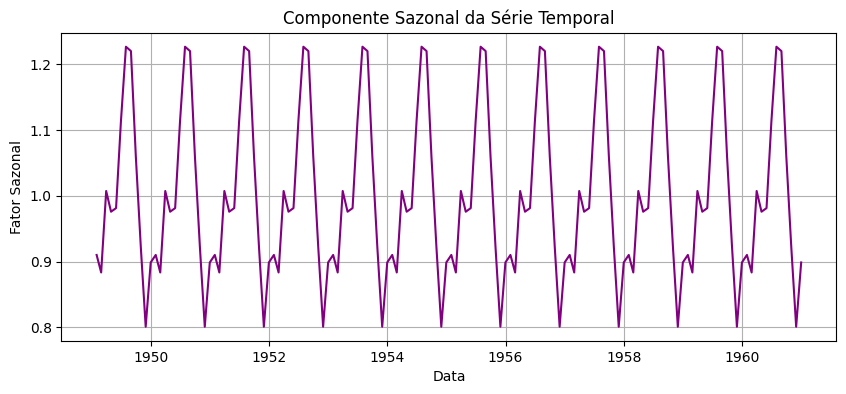

In [46]:
# Importa a biblioteca matplotlib para visualização de gráficos.
import matplotlib.pyplot as plt
# Importa a função seasonal_decompose da biblioteca statsmodels para decomposição de séries temporais.
from statsmodels.tsa.seasonal import seasonal_decompose

# --- Realiza a Decomposição Sazonal ---
# Realiza a decomposição da série temporal 'data' em seus componentes: tendência, sazonalidade e resíduo.
# 'model="multiplicative"' é apropriado quando a magnitude dos padrões sazonais cresce ou diminui com o nível da série.
# 'period=12' especifica que o padrão sazonal se repete a cada 12 pontos (neste caso, meses, para dados mensais).
decomposition = seasonal_decompose(data, model='multiplicative', period=12)

# --- Visualiza a Decomposição Completa ---
# Cria uma nova figura para agrupar os gráficos da decomposição.
# O método .plot() da decomposição automaticamente cria subplots para cada componente:
# Série Original, Tendência, Sazonalidade e Resíduo.
decomposition.plot()
# Define o título geral para o conjunto de gráficos da decomposição.
plt.suptitle('Decomposição da Série Temporal em Tendência, Sazonalidade e Resíduo', y=1.02)
# Ajusta o layout para evitar que os títulos e rótulos se sobreponham.
plt.tight_layout()
# Exibe a figura com todos os gráficos da decomposição.
plt.show()

# --- Visualiza o Componente Sazonal Separadamente ---
# Para analisar o componente sazonal individualmente com mais detalhes, podemos plotá-lo separadamente.
plt.figure(figsize=(10, 4))
# Acessa e plota o componente sazonal da decomposição.
plt.plot(decomposition.seasonal, color='purple')
# Define o título do gráfico do componente sazonal.
plt.title('Componente Sazonal da Série Temporal')
# Define o rótulo do eixo X.
plt.xlabel('Data')
# Define o rótulo do eixo Y, indicando o fator ou efeito sazonal (para modelo multiplicativo).
plt.ylabel('Fator Sazonal')
# Adiciona uma grade ao gráfico para facilitar a leitura dos valores.
plt.grid(True)
# Exibe o gráfico do componente sazonal.
plt.show()

### Interpretação dos Gráficos de Decomposição

Ao realizar a decomposição de uma série temporal usando `seasonal_decompose`, obtemos quatro gráficos principais que nos ajudam a entender a estrutura subjacente dos dados:

1.  **Observed (Série Observada):**
    *   Este é o gráfico da sua série temporal original. Ele mostra os dados como foram coletados e serve como ponto de partida para a análise.
    *   Permite visualizar a série em sua totalidade, incluindo tendências, padrões sazonais e quaisquer anomalias.

2.  **Trend (Tendência):**
    *   Representa o movimento de longo prazo da série temporal. É a direção geral dos dados, ignorando as flutuações de curto prazo e os padrões sazonais.
    *   Uma tendência crescente indica que os valores da série estão aumentando ao longo do tempo, enquanto uma tendência decrescente sugere uma diminuição. Uma tendência horizontal indica que não há um movimento de longo prazo significativo.
    *   É calculada usando uma média móvel da série, que suaviza as oscilações.

3.  **Seasonal (Sazonalidade):**
    *   Este componente captura os padrões que se repetem em intervalos fixos (por exemplo, mensalmente, trimestralmente, anualmente).
    *   A sazonalidade indica variações regulares e previsíveis que ocorrem dentro de um período específico.
    *   Em um modelo multiplicativo (como o que usamos aqui), os valores sazonais são fatores que multiplicam a tendência para formar a série original, o que significa que a magnitude da sazonalidade pode variar com o nível da série.

4.  **Residual (Resíduo ou Ruído):**
    *   Também conhecido como componente irregular ou ruído, o resíduo é o que resta da série temporal após a remoção da tendência e da sazonalidade.
    *   Representa as flutuações imprevisíveis e aleatórias na série. Idealmente, os resíduos devem ser ruído branco (sem padrão ou correlação). Se houver padrões nos resíduos, isso pode indicar que o modelo de decomposição não capturou toda a estrutura da série.
    *   Analise os resíduos para identificar outliers, eventos incomuns ou estruturas não modeladas.

### Como Interpretar em Conjunto:

*   **Modelo Multiplicativo:** Se você escolheu `model='multiplicative'`, a série observada é aproximadamente o produto da tendência, sazonalidade e resíduo: `Observed = Trend × Seasonal × Residual`.
*   **Série sem Sazonalidade/Tendência:** Se um dos componentes parecer uma linha plana ou ruído, isso sugere que a série não possui uma sazonalidade ou tendência forte, respectivamente.
*   **Análise de Anomalias:** Picos ou vales incomuns nos resíduos podem apontar para anomalias ou eventos externos que afetaram a série.

Esses gráficos fornecem uma visão intuitiva da composição da série temporal, ajudando a identificar padrões importantes e a preparar os dados para modelagem futura.